In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df_veh = pd.read_csv('../data/cleaned/Vehicle_Filtered.csv')
df_veh

,COLLISIONVEHDETKEY,COLDETKEY,ST_VEH_TYPE_DESC_RAW,ST_VEH_TYPE_DESC,VEHICLE_CATEGORY,Incident Date,YEAR
0,895659,385408,Passenger Car,Passenger Vehicle,Passenger Vehicle,2024-11-17,2024
1,651656,230400,"Pickup, Panel Truck or Vannette Under 10,000 lbs",Light Truck/Van,Light Truck/Van,2016-10-27,2016
2,651657,230400,"Pickup, Panel Truck or Vannette Under 10,000 lbs",Light Truck/Van,Light Truck/Van,2016-10-27,2016
3,904715,385614,Passenger Car,Passenger Vehicle,Passenger Vehicle,2025-08-27,2025
4,904716,385614,"Pickup, Panel Truck or Vannette Under 10,000 lbs",Light Truck/Van,Light Truck/Van,2025-08-27,2025
...,...,...,...,...,...,...,...
160690,898841,379695,Motorcycle,Two-Wheeled,Two-Wheeled,2024-12-24,2024
160691,898842,379695,Passenger Car,Passenger Vehicle,Passenger Vehicle,2024-12-24,2024
160692,898698,379817,Not Stated,Unknown,Unknown,2024-12-13,2024
160693,898699,379817,"Pickup, Panel Truck or Vannette Under 10,000 lbs",Light Truck/Van,Light Truck/Van,2024-12-13,2024


ST_VEH_TYPE_DESC
Bus                   2015
Commercial Truck      5144
Light Truck/Van      59249
Other                  489
Passenger Vehicle    82616
Railway Vehicle        128
Two-Wheeled           1790
Unknown               9264
dtype: int64


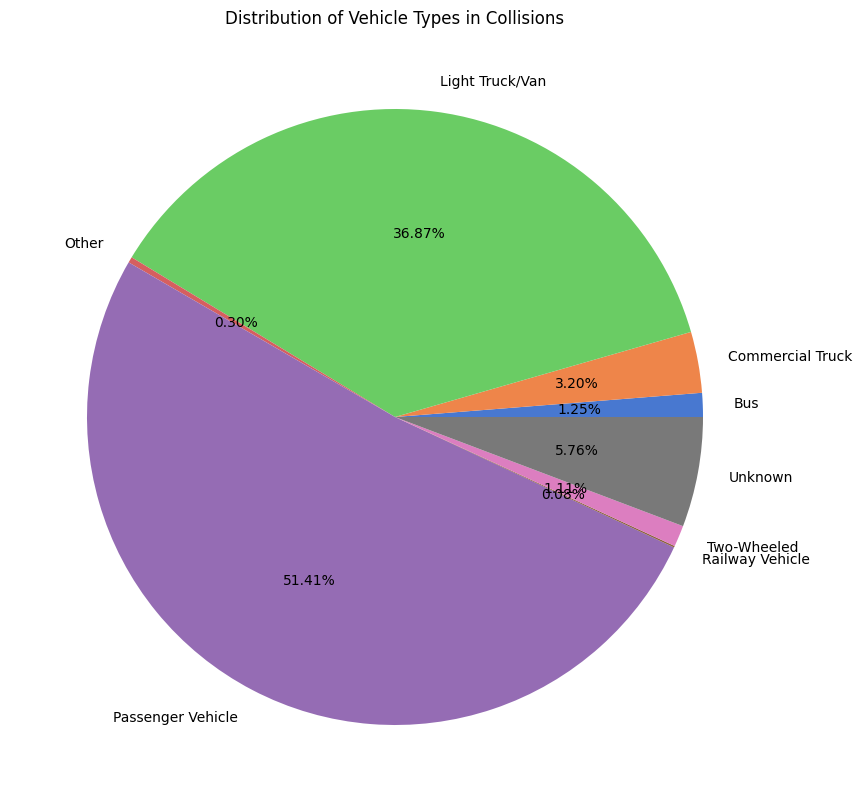

In [9]:
df_veh_size = df_veh.groupby('ST_VEH_TYPE_DESC').size()
print(df_veh_size)

labels = np.unique(df_veh_size.index)
plt.figure(figsize=(10,10))
plt.pie(df_veh_size, labels=labels, autopct='%.2f%%', colors=sns.color_palette('muted', len(labels)))
plt.title('Distribution of Vehicle Types in Collisions')
plt.show()

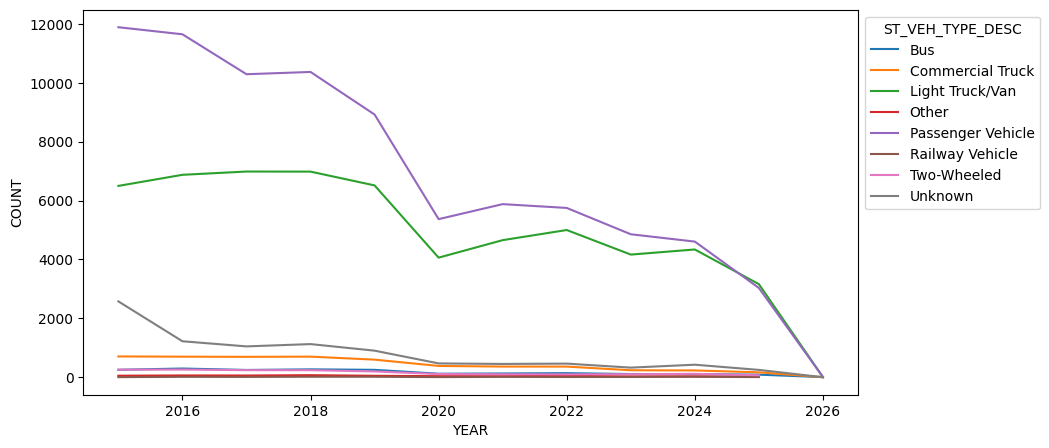

In [13]:
plt.figure(figsize=(10,5))
df_veh_group = pd.DataFrame(df_veh.groupby(['YEAR', 'ST_VEH_TYPE_DESC']).size().reset_index()).rename(columns={0: 'COUNT'})
df_veh_group = df_veh_group[df_veh_group['YEAR'] > 2014]

veh_plot = sns.lineplot(data=df_veh_group, x='YEAR', y='COUNT', hue='ST_VEH_TYPE_DESC', legend=True)
sns.move_legend(
    veh_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.tight_layout
plt.show()